# SE4_generate_outputs

**Author:** Md Zobayer Hossain Taki, University of Oulu 
**Repository:** [GitHub – cloud_swatplus_nrt_pipeline] 

---

## Purpose of this notebook
This is the **final step** of the reproducible pipeline (SE1 → SE4).  
It reads all outputs written by SE3 and produces **publication-quality figures, tables, and an interactive forecast dashboard**. No model training or data processing occurs here.

## Inputs (all read from disk)
| File | Written by | Used for |
|------|-----------|----------|
| `predictions.csv` | SE3 Part B | Figures 1, 7, dashboard |
| `predictions_calval.csv` | SE3 Part A | Figures 1, 2, 3, 5 |
| `evaluation_metrics.csv` | SE3 Part A | Figures 4, Table 1 |
| `sensitivity_results.csv` | SE3 Part A | Figure 6 |
| `Observed_data_standard_format_1.txt` | SE1 Part C | Figure 7 historical band |
| `model/config/model_config.yaml` | SE3 | Period dates for all figures |
| `Shapes/` | SE1 Part A (Zenodo) | Dashboard GIS map |

## Outputs
All written to `oulanka_swatplus_processeddata/outputs/`.

| File | Description |
|------|-------------|
| `fig01_hydrograph.png` | Full-period observed vs simulated hydrograph |
| `fig02_scatter.png` | Observed vs predicted scatter by period |
| `fig03_fdc.png` | Flow Duration Curve — validation period |
| `fig04_metrics_panel.png` | NSE, KGE, R², PBIAS panel |
| `fig05_seasonal_residuals.png` | Monthly residual box plots |
| `fig06_sensitivity.png` | Sobol sensitivity top 20 parameters |
| `table01_metrics.csv` | Performance metrics CSV |
| `table01_metrics.tex` | Performance metrics LaTeX |
| `forecast_dashboard.html` | Interactive dashboard: historical band + forecast + GIS map |

## Visualisation guidelines
All figures follow **Kelleher & Wagener (2011)** ten guidelines.  
**Colour palette:** Okabe-Ito (colourblind-safe throughout).

## Cell 1 — Load dependencies

Run this cell every time.

In [1]:
# Modify cell
from pathlib import Path
import os
import json
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import plotly.graph_objects as go          # pip install plotly
import folium                              # pip install folium
import folium.plugins as plugins
import geopandas as gpd                    # pip install geopandas
from IPython.display import display

# --- Consistent figure style across all SE4 outputs (Guideline 8) ---
plt.rcParams.update({
    "font.size"        : 10,
    "axes.titlesize"   : 11,
    "axes.labelsize"   : 10,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "legend.fontsize"  : 9,
    "figure.dpi"       : 150,
    "savefig.dpi"      : 300,
    "savefig.bbox"     : "tight",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

# Okabe-Ito colourblind-safe palette (Guideline 5)
C_BLUE   = "#0072B2"
C_ORANGE = "#E69F00"
C_GREEN  = "#009E73"
C_RED    = "#D55E00"
C_PURPLE = "#CC79A7"
C_SKY    = "#56B4E9"

print("Dependencies loaded. Okabe-Ito palette ready.")

Dependencies loaded. Okabe-Ito palette ready.


## Directory setup

All inputs are read from the processed data directory (written by SE1–SE3).  
All outputs are written to the outputs subdirectory outside the repository.

In [2]:
# Automatically generated cell — resolve external directories
# Current working directory = project/notebooks
notebook_dir  = Path.cwd()
project_root  = notebook_dir.parent
external_base = project_root.parent

# Read from processed data directory (written by SE1–SE3)
proc_data_dir = external_base / "oulanka_swatplus_processeddata"
pred_dir      = proc_data_dir / "predictions"
model_dir     = proc_data_dir / "model"
config_dir    = model_dir / "config"

# Write all publication outputs here
output_dir = proc_data_dir / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

# ── USER SETTINGS ─────────────────────────────────────────────────────────────
TARGET_UNIT   = 891

# Auto-detect Shapes folder from Zenodo extraction
zenodo_dir      = external_base / "oulanka_swatplus_rawdata" / "zenodo_data"
shapes_hits     = list(zenodo_dir.rglob("subs1.shp"))
SHAPE_DIR       = str(shapes_hits[0].parent) if shapes_hits else str(zenodo_dir / "Shapes")

# SYKE observed flow file — raw data stored in rawdata/SYKE/ (industry standard)
# Written by SE1 Part C; read here for historical band in dashboard
syke_dir      = external_base / "oulanka_swatplus_rawdata" / "SYKE"
OBSERVED_FILE = str(syke_dir / "Observed_data_standard_format_1.txt")

print("Reading from :", proc_data_dir.resolve())
print("Writing to   :", output_dir.resolve())
print("Shapes dir   :", SHAPE_DIR)
print("Observed file:", OBSERVED_FILE,
      "[EXISTS]" if Path(OBSERVED_FILE).exists() else "[NOT FOUND — run SE1 Part C]")

Reading from : /home/jovyan/oulanka_swatplus_processeddata
Writing to   : /home/jovyan/oulanka_swatplus_processeddata/outputs
Shapes dir   : /home/jovyan/oulanka_swatplus_rawdata/zenodo_data/Shapes
Observed file: /home/jovyan/oulanka_swatplus_rawdata/SYKE/Observed_data_standard_format_1.txt [EXISTS]


In [3]:
!df -k ..
# Confirm sufficient storage before writing figures.

Filesystem     1K-blocks      Used Available Use% Mounted on
/dev/sdb       514937088 467255060  47665644  91% /home/jovyan


## Cell 2 — Load all inputs from disk

All data is loaded from files written by SE1–SE3.  
**Never re-run model training here.**

In [4]:
# Modify cell

# Load model configuration
with open(config_dir / "model_config.yaml") as f:
    cfg = yaml.safe_load(f)
print("Model config loaded.")

# Load calibration/validation observed vs simulated (from SE3 Cell 9)
df_calval = pd.read_csv(pred_dir / "predictions_calval.csv", parse_dates=['date'])
df_calval = df_calval.set_index('date').sort_index()
print(f"Calibration/validation : {len(df_calval)} days")

# Load daily predictions — full period including forecast (from SE3 Cell 12)
df_pred = pd.read_csv(pred_dir / "predictions.csv", parse_dates=['Date'])
df_pred = df_pred.set_index('Date').sort_index()
print(f"Predictions            : {len(df_pred)} days "
      f"({df_pred.index.min().date()} to {df_pred.index.max().date()})")

# Load evaluation metrics
metrics_df = pd.read_csv(pred_dir / "evaluation_metrics.csv", index_col=0)
print("\nEvaluation metrics:")
print(metrics_df.round(3))

# Load Sobol sensitivity results
sens_df = pd.read_csv(pred_dir / "sensitivity_results.csv")
print(f"\nSensitivity results : {len(sens_df)} parameters")

# Load SYKE historical observed flow (for historical band in dashboard)
if Path(OBSERVED_FILE).exists():
    df_hertta = pd.read_csv(OBSERVED_FILE)
    df_hertta['date'] = pd.to_datetime(df_hertta['date'], format='%d-%m-%Y')
    df_hertta['MonthDay'] = df_hertta['date'].dt.strftime('%m-%d')
    flow_col = [c for c in df_hertta.columns if c.endswith('_q')][0]
    print(f"SYKE historical flow   : {len(df_hertta)} days | column: {flow_col}")
else:
    df_hertta = None
    flow_col  = None
    print("WARNING: Observed flow file not found. Historical band in dashboard will be disabled.")
    print(f"  Expected at: {OBSERVED_FILE}")
    print("  Run SE1 Part C (Cell 7) to download from SYKE API.")

# Extract the last 3 rows — these are the forecast days
df_forecast_rows = df_pred.tail(3).reset_index()
print("\n3-Day Forecast:")
print(df_forecast_rows[['Date','flo_out','TN','TP']].to_string(index=False))

FileNotFoundError: [Errno 2] No such file or directory: '/home/jovyan/oulanka_swatplus_processeddata/model/config/model_config.yaml'

---
## Figure 1 — Full-period hydrograph: observed vs simulated

**Guideline 1:** Simple line plot.  
**Guideline 7:** Shaded regions show calibration and validation periods.

NameError: name 'df_calval' is not defined

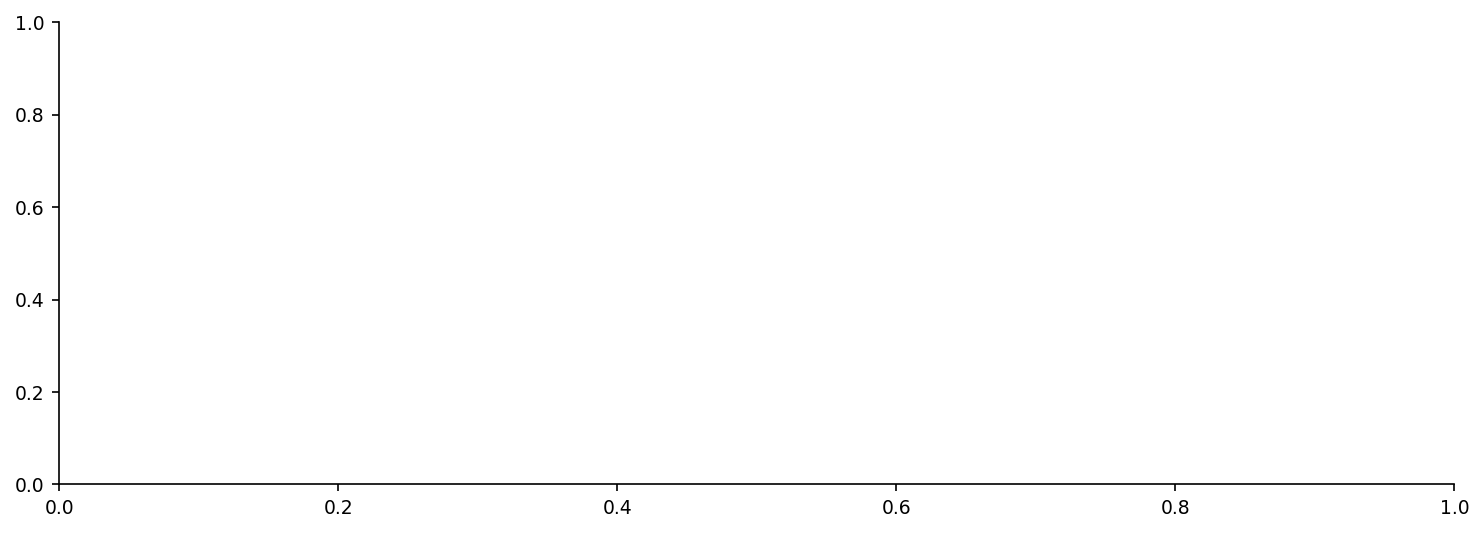

In [5]:
# Modify cell
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df_calval.index, df_calval['obs_q'],
        color=C_BLUE, lw=1.2, label='Observed (m³/s)', zorder=3)
ax.plot(df_calval.index, df_calval['flo_out'],
        color=C_RED,  lw=1.0, label='Simulated (m³/s)', zorder=2)

ax.axvspan(pd.Timestamp(cfg['periods']['calibration_start']),
           pd.Timestamp(cfg['periods']['calibration_end']),
           alpha=0.08, color=C_GREEN,  label='Calibration')
ax.axvspan(pd.Timestamp(cfg['periods']['validation_start']),
           pd.Timestamp(cfg['periods']['validation_end']),
           alpha=0.08, color=C_ORANGE, label='Validation')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.set_xlabel('Date')
ax.set_ylabel('Streamflow (m³/s)')

nse_c = metrics_df.loc['calibration','NSE'] if 'calibration' in metrics_df.index else float('nan')
nse_v = metrics_df.loc['validation', 'NSE'] if 'validation'  in metrics_df.index else float('nan')
ax.set_title(
    f"Fig. 1 — Oulanka River: Observed vs Simulated Streamflow\n"
    f"Calibration NSE = {nse_c:.3f}   Validation NSE = {nse_v:.3f}"
)
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.savefig(output_dir / "fig01_hydrograph.png")
plt.show()
print("Figure 1 saved.")

## Figure 2 — Observed vs predicted scatter

**Guideline 2:** Position encodes quantitative accuracy.  
**Guideline 7:** Dashed 1:1 line is the perfect-model reference.

In [6]:
# Modify cell
calib_mask = (
    (df_calval.index >= cfg['periods']['calibration_start']) &
    (df_calval.index <= cfg['periods']['calibration_end'])
)
valid_mask = (
    (df_calval.index >= cfg['periods']['validation_start']) &
    (df_calval.index <= cfg['periods']['validation_end'])
)

fig, ax = plt.subplots(figsize=(5, 5))
for mask, colour, label in [
    (calib_mask, C_GREEN,  'Calibration'),
    (valid_mask, C_ORANGE, 'Validation')
]:
    ax.scatter(df_calval.loc[mask,'obs_q'], df_calval.loc[mask,'flo_out'],
               s=5, alpha=0.4, color=colour, label=label, rasterized=True)

lims = [df_calval[['obs_q','flo_out']].min().min(),
        df_calval[['obs_q','flo_out']].max().max()]
ax.plot(lims, lims, 'k--', lw=0.8, label='1:1 line')
ax.set_xlabel('Observed streamflow (m³/s)')
ax.set_ylabel('Simulated streamflow (m³/s)')
ax.set_title('Fig. 2 — Observed vs Predicted Streamflow')
ax.legend(frameon=False, markerscale=2)
plt.tight_layout()
plt.savefig(output_dir / "fig02_scatter.png")
plt.show()
print("Figure 2 saved.")

NameError: name 'df_calval' is not defined

## Figure 3 — Flow Duration Curve (validation period)

**Guideline 3:** Pattern plot — reveals model skill across the full flow regime.  
**Guideline 4:** Log scale appropriate for streamflow.

In [7]:
# Modify cell
def compute_fdc(series):
    """Return (exceedance probability, sorted flows) for a Flow Duration Curve."""
    sorted_vals = np.sort(series.dropna().values)[::-1]
    exceedance  = np.arange(1, len(sorted_vals) + 1) / (len(sorted_vals) + 1)
    return exceedance, sorted_vals

valid_df = df_calval.loc[
    cfg['periods']['validation_start'] : cfg['periods']['validation_end']
]
exc_obs, q_obs = compute_fdc(valid_df['obs_q'])
exc_sim, q_sim = compute_fdc(valid_df['flo_out'])

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(exc_obs * 100, q_obs, color=C_BLUE, lw=1.4, label='Observed')
ax.semilogy(exc_sim * 100, q_sim, color=C_RED,  lw=1.0, label='Simulated', ls='--')
ax.set_xlabel('Exceedance probability (%)')
ax.set_ylabel('Streamflow (m³/s, log scale)')
ax.set_title('Fig. 3 — Flow Duration Curve: Validation Period')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(output_dir / "fig03_fdc.png")
plt.show()
print("Figure 3 saved.")

NameError: name 'df_calval' is not defined

## Figure 4 — Performance metrics panel

**Guideline 9:** Small multiples — one subplot per metric.  
**Guideline 7:** Dashed reference lines mark the no-skill threshold.

In [ ]:
# Modify cell
plot_metrics  = ['NSE', 'KGE', 'R2', 'PBIAS']
plot_splits   = [s for s in ['calibration','validation'] if s in metrics_df.index]
ref_lines     = {'NSE': 0, 'KGE': 0, 'R2': 0}
split_colours = {'calibration': C_GREEN, 'validation': C_ORANGE}

fig, axes = plt.subplots(1, len(plot_metrics), figsize=(len(plot_metrics) * 2.5, 3.5))
x = np.arange(len(plot_splits))

for ax, metric in zip(axes, plot_metrics):
    vals    = [metrics_df.loc[sp, metric] for sp in plot_splits]
    colours = [split_colours[sp] for sp in plot_splits]
    ax.bar(x, vals, color=colours, edgecolor='none', width=0.6)
    if metric in ref_lines:
        ax.axhline(ref_lines[metric], color='k', lw=0.7, ls='--')
    ax.set_title(metric, fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels([s[:3].capitalize() for s in plot_splits], fontsize=8)

fig.suptitle('Fig. 4 — Model Performance Metrics', fontsize=10, y=1.02)
handles = [Patch(color=split_colours[s], label=s.capitalize()) for s in plot_splits]
fig.legend(handles=handles, frameon=False, loc='upper center',
           bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig(output_dir / "fig04_metrics_panel.png")
plt.show()
print("Figure 4 saved.")

## Figure 5 — Seasonal residual box plots

**Guideline 3:** Box plots reveal seasonal bias patterns — ideal for detecting snowmelt timing errors.

In [ ]:
# Modify cell
valid_copy = df_calval.loc[
    cfg['periods']['validation_start'] : cfg['periods']['validation_end']
].copy()
valid_copy['residual'] = valid_copy['flo_out'] - valid_copy['obs_q']
valid_copy['month']    = valid_copy.index.month_name().str[:3]

month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 3.5))
groups = [valid_copy.loc[valid_copy['month'] == m, 'residual'].dropna().values
          for m in month_order]
ax.boxplot(
    groups, labels=month_order, patch_artist=True,
    medianprops=dict(color='black', lw=1.5),
    boxprops=dict(facecolor=C_SKY, alpha=0.7),
    flierprops=dict(marker='.', ms=3, alpha=0.3)
)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Month')
ax.set_ylabel('Residual: simulated − observed (m³/s)')
ax.set_title('Fig. 5 — Seasonal Distribution of Model Residuals: Validation Period')
plt.tight_layout()
plt.savefig(output_dir / "fig05_seasonal_residuals.png")
plt.show()
print("Figure 5 saved.")

## Figure 6 — Sobol sensitivity bar chart

**Guideline 2:** Horizontal stacked bars — S1 and interaction effect immediately visible.

In [ ]:
# Modify cell
sens_df['S1'] = sens_df['S1'].clip(lower=0)
sens_df['ST'] = sens_df['ST'].clip(lower=0)
top20 = sens_df.nlargest(20, 'ST').sort_values('ST', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top20['parameter'], top20['S1'],
        label='First-order (S1)', color=C_BLUE, alpha=0.85)
ax.barh(top20['parameter'], top20['ST'] - top20['S1'],
        left=top20['S1'],
        label='Interaction effects (ST − S1)', color=C_ORANGE, alpha=0.75)
ax.set_xlabel('Sobol Sensitivity Index')
ax.set_title('Fig. 6 — Top 20 SWAT+ Parameters by Total-Order Sensitivity (ST)\nOulanka River')
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(output_dir / "fig06_sensitivity.png")
plt.show()
print("Figure 6 saved.")

## Table 1 — Model performance metrics

Exported as CSV and LaTeX for direct insertion into the thesis manuscript.

In [ ]:
# Modify cell
table = metrics_df.copy()
table.to_csv(output_dir / "table01_metrics.csv")
print(f"Table 1 CSV saved: {output_dir / 'table01_metrics.csv'}")

print("\n--- Markdown (copy into README) ---")
print(table.round(4).to_markdown())

table.style.format(precision=4).to_latex(
    output_dir / "table01_metrics.tex",
    caption="SWAT+ model performance metrics for the Oulanka River catchment.",
    label="tab:metrics",
    position="h"
)
print(f"LaTeX table saved: {output_dir / 'table01_metrics.tex'}")

---
# Interactive Forecast Dashboard

The dashboard integrates three elements into a single standalone HTML file:

1. **Plotly chart** — historical climatology band (25th–75th percentile from SYKE 1961–2022) + historical maximum + past 7 days simulation + 3-day forecast + KPI annotation
2. **Folium GIS map** — watershed boundary, subbasins, river network, clickable outlet marker with popup forecast table and mini-chart

**Guideline 10:** Tailored to operational audience — interactive, shareable as a standalone HTML file.

## Cell 3 — Build historical climatology band from SYKE data

For each date in the 10-day display window, the 25th percentile, 75th percentile, and historical maximum
are computed from all matching calendar days in the SYKE record (1961–2022).
This gives hydrological context: is today's flow unusually high or low for this time of year?

In [8]:
# ==========================================
# CELL 3: BUILD HISTORICAL BAND FROM SYKE DATA
# ==========================================

# Use last 10 rows of predictions: past 7 simulated days + 3 forecast days
df_display = df_pred.tail(10).reset_index().copy()

# Split into past (observed-period simulation) and forecast using today's date
today      = pd.Timestamp.now().normalize()
past_mask  = df_display['Date'] < today
fcast_mask = df_display['Date'] >= today

# Compute historical band for each date in the display window
upper_band, lower_band, hist_max = [], [], []

if df_hertta is not None:
    for dt in df_display['Date']:
        md         = dt.strftime('%m-%d')
        hist_vals  = df_hertta[df_hertta['MonthDay'] == md][flow_col].dropna()
        if not hist_vals.empty:
            upper_band.append(float(hist_vals.quantile(0.75)))
            lower_band.append(float(hist_vals.quantile(0.25)))
            hist_max.append(float(hist_vals.max()))
        else:
            # Fallback if no matching calendar day in SYKE record
            upper_band.append(np.nan)
            lower_band.append(np.nan)
            hist_max.append(np.nan)
    print(f"Historical band computed for {len(df_display)} dates.")
else:
    # SYKE data not available — use empty arrays
    upper_band = [np.nan] * len(df_display)
    lower_band = [np.nan] * len(df_display)
    hist_max   = [np.nan] * len(df_display)
    print("WARNING: SYKE data not loaded. Historical band will not appear in dashboard.")

NameError: name 'df_pred' is not defined

## Cell 4 — Plotly interactive forecast chart

Combines the historical climatology band, historical maximum, past 7-day simulation,
and 3-day forecast into a single interactive chart with a KPI annotation box.

In [9]:
# ==========================================
# CELL 4: PLOTLY INTERACTIVE FORECAST CHART
# ==========================================

fig_plotly = go.Figure()

# --- Historical Maximum line ---
fig_plotly.add_trace(go.Scatter(
    x=df_display['Date'], y=hist_max,
    mode='lines', name='Historical Maximum (1961–2022)',
    line=dict(color='rgba(213, 94, 0, 0.6)', width=2, dash='dashdot')
))

# --- Historical percentile band (25th–75th) ---
# Filled polygon built by concatenating upper and reversed lower bands
fig_plotly.add_trace(go.Scatter(
    x=df_display['Date'].tolist() + df_display['Date'].tolist()[::-1],
    y=upper_band + lower_band[::-1],
    fill='toself',
    fillcolor='rgba(128, 128, 128, 0.2)',
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo='skip',
    showlegend=True,
    name='Normal Range (25th–75th percentile)'
))

# --- Past 7 days simulation (solid line) ---
df_past = df_display[past_mask]
fig_plotly.add_trace(go.Scatter(
    x=df_past['Date'], y=df_past['flo_out'],
    mode='lines+markers', name='Past 7 Days Simulation',
    line=dict(color=C_BLUE, width=4, dash='solid')
))

# --- 3-day forecast (dotted line, same colour) ---
# Overlap by one point with past line so the lines connect visually
connect_idx = df_display[past_mask].index[-1] if past_mask.any() else df_display.index[0]
df_fcast    = df_display.loc[connect_idx:][fcast_mask.loc[connect_idx:] | (df_display.index == connect_idx)]
fig_plotly.add_trace(go.Scatter(
    x=df_fcast['Date'], y=df_fcast['flo_out'],
    mode='lines+markers', name='3-Day Forecast',
    line=dict(color=C_BLUE, width=4, dash='dot')
))

# --- KPI annotation box (top-right corner) ---
nse_c = metrics_df.loc['calibration','NSE'] if 'calibration' in metrics_df.index else float('nan')
r2_c  = metrics_df.loc['calibration','R2']  if 'calibration' in metrics_df.index else float('nan')
fig_plotly.add_annotation(
    text=f"<b>Model Accuracy (Calibration):</b><br>NSE: {nse_c:.3f}<br>R²: {r2_c:.3f}",
    align='left', showarrow=False,
    xref='paper', yref='paper', x=1.02, y=1.0,
    bgcolor='rgba(240,240,240,0.9)', bordercolor='#CCCCCC', borderwidth=1
)

fig_plotly.update_layout(
    title=f"Oulanka River (Unit {TARGET_UNIT}) — 10-Day Prediction vs Historical Climatology",
    xaxis_title='Date',
    yaxis_title='Streamflow (m³/s)',
    template='plotly_white',
    legend=dict(yanchor='top', y=0.99, xanchor='left', x=0.01),
    margin=dict(r=150)
)

fig_plotly.show()
print("Interactive Plotly chart rendered.")

NameError: name 'df_display' is not defined

## Cell 5 — Folium GIS map with forecast popup

In [10]:
# ==========================================
# CELL 5: FOLIUM GIS MAP WITH FORECAST POPUP
# ==========================================

m = folium.Map(location=[66.36, 29.32], zoom_start=10, tiles='cartodbpositron')

folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri', name='Satellite Imagery', overlay=False
).add_to(m)

# --- Load GIS shapefiles (auto-detected from Zenodo extraction in SE1) ---
try:
    wshed_path = os.path.join(SHAPE_DIR, "dem_fwshed_dem.shp")
    if os.path.exists(wshed_path):
        wshed_gdf = gpd.read_file(wshed_path).to_crs(epsg=4326)
        folium.GeoJson(
            wshed_gdf, name='Catchment Boundary',
            style_function=lambda x: {'color': C_BLUE, 'weight': 3, 'fillOpacity': 0}
        ).add_to(m)

    subs_path = os.path.join(SHAPE_DIR, "subs1.shp")
    if os.path.exists(subs_path):
        subs_gdf = gpd.read_file(subs_path).to_crs(epsg=4326)
        folium.GeoJson(
            subs_gdf, name='Subbasins',
            style_function=lambda x: {
                'color': '#555555', 'weight': 0.8,
                'fillColor': '#E6E6E6', 'fillOpacity': 0.15
            }
        ).add_to(m)

    rivs_path = os.path.join(SHAPE_DIR, "rivs1.shp")
    if os.path.exists(rivs_path):
        rivs_gdf = gpd.read_file(rivs_path).to_crs(epsg=4326)
        folium.GeoJson(
            rivs_gdf, name='River Network',
            style_function=lambda x: {'color': C_SKY, 'weight': 1.5}
        ).add_to(m)

    print("GIS shapefiles loaded.")
except Exception as e:
    print(f"WARNING: could not load shapefiles: {e}")
    print(f"Check SHAPE_DIR: {SHAPE_DIR}")

# --- Build forecast popup ---
table_rows = ""
for _, row in df_forecast_rows.iterrows():
    date_str    = row['Date'].strftime('%b %d')
    table_rows += (
        f"<tr>"
        f"<td style='padding:3px'>{date_str}</td>"
        f"<td style='color:{C_BLUE}'><b>{round(row['flo_out'],2)}</b></td>"
        f"<td style='color:{C_GREEN}'>{round(row['TN'],3)}</td>"
        f"<td style='color:{C_RED}'>{round(row['TP'],4)}</td>"
        f"</tr>"
    )

dates_js = json.dumps(df_forecast_rows['Date'].dt.strftime('%b %d').tolist())
flow_js  = json.dumps(df_forecast_rows['flo_out'].round(2).tolist())

popup_html = f"""
<!DOCTYPE html><html>
<head><script src="https://cdn.plot.ly/plotly-latest.min.js"></script></head>
<body style="font-family:Arial; margin:0; padding:6px; width:310px;">
  <h4 style="text-align:center; margin:0 0 6px 0; color:#333;">
    Oulanka Outlet (Unit {TARGET_UNIT})
  </h4>
  <table style="width:100%; border-collapse:collapse; font-size:11px; text-align:center;">
    <tr style="background:#F0F0F0; border-bottom:2px solid #CCC;">
      <th style='padding:3px'>Date</th>
      <th>Flow (m³/s)</th><th>TN (kg)</th><th>TP (kg)</th>
    </tr>
    {table_rows}
  </table>
  <div id="mini" style="width:100%; height:140px; margin-top:6px;"></div>
  <script>
    Plotly.newPlot(
      'mini',
      [{{x:{dates_js}, y:{flow_js}, type:'scatter', mode:'lines+markers',
        line:{{color:'{C_BLUE}', width:3}}}}],
      {{margin:{{l:35,r:10,t:10,b:25}}, yaxis:{{title:'Flow (m³/s)'}}}},
      {{displayModeBar:false}}
    );
  </script>
</body></html>
"""

folium.Marker(
    [66.36, 29.32],
    popup=folium.Popup(
        folium.IFrame(html=popup_html, width=330, height=310), max_width=330
    ),
    tooltip='Click: 3-Day Forecast',
    icon=folium.Icon(color='red', icon='tint', prefix='fa')
).add_to(m)

folium.LayerControl(position='topright', collapsed=False).add_to(m)
plugins.Fullscreen(position='topleft').add_to(m)

display(m)
print("GIS map rendered.")

GIS shapefiles loaded.


NameError: name 'df_forecast_rows' is not defined

## Cell 6 — Save dashboard as standalone HTML

In [ ]:
# ==========================================
# CELL 6: SAVE STANDALONE HTML DASHBOARD
# ==========================================

dashboard_html = output_dir / "forecast_dashboard.html"

# Save the Folium map as the base HTML
m.save(str(dashboard_html))

# Inject the Plotly chart HTML above the map by editing the saved file
plotly_html = fig_plotly.to_html(
    full_html=False,
    include_plotlyjs='cdn',
    config={'displayModeBar': True, 'scrollZoom': True}
)

with open(dashboard_html, 'r', encoding='utf-8') as f:
    map_html_content = f.read()

# Insert Plotly chart div before the closing </body> tag
chart_wrapper = (
    "<div style='margin:20px; padding:10px; "
    "background:white; border-radius:8px; "
    "box-shadow:0 2px 8px rgba(0,0,0,0.15);'>"
    + plotly_html +
    "</div>"
)
combined_html = map_html_content.replace('</body>', chart_wrapper + '</body>')

with open(dashboard_html, 'w', encoding='utf-8') as f:
    f.write(combined_html)

print(f"Dashboard saved: {dashboard_html}")
print("Open this file in a browser to view the full interactive dashboard.")

---
## Summary of outputs

| File | Description |
|------|-------------|
| `fig01_hydrograph.png` | Full-period observed vs simulated streamflow |
| `fig02_scatter.png` | Observed vs predicted scatter by period |
| `fig03_fdc.png` | Flow Duration Curve — validation period |
| `fig04_metrics_panel.png` | NSE, KGE, R², PBIAS panel |
| `fig05_seasonal_residuals.png` | Monthly residual box plots |
| `fig06_sensitivity.png` | Sobol sensitivity top 20 parameters |
| `table01_metrics.csv` | Performance metrics CSV |
| `table01_metrics.tex` | Performance metrics LaTeX |
| `forecast_dashboard.html` | Interactive dashboard: historical band + forecast + GIS map |

## Interpretation guide
- **Historical band:** Grey shading = normal flow range for this time of year (25th–75th percentile, 1961–2022 SYKE data). Flow above the band = unusually high; below = unusually low.
- **Historical maximum:** Orange dashed line = highest ever recorded flow for this calendar date.
- **Solid blue line:** Past 7 days of SWAT+ simulation.
- **Dotted blue line:** 3-day Harmonie NWP forecast.

---
## Need help?
https://github.com/orgs/DigitalWaters-fi/discussions — Tag **#outputs**